# Calculate and Plot Activity

Given an existing database for Al-Zn, we would like to calculate the activity of the liquid.

## Experimental activity results

In order to make sure we are correct, we'll compare the values with experimental results.
Experimental activities are digitized from Fig. 18 in [A. Yazawa, Y.K. Lee, Thermodynamic Studies of the Liquid Aluminum Alloy Systems, Trans. Japan Inst. Met. 11 (1970) 411–418](https://doi.org/10.2320/matertrans1960.11.411).

The measurements at at 1073 K and they used a reference state of the pure Zn at that temperature.


In [1]:
exp_x_zn =   [0.0482, 0.1990, 0.3550, 0.5045, 0.6549, 0.8070, 0.9569]
exp_acr_zn = [0.1154, 0.3765, 0.5411, 0.6433, 0.7352, 0.8384, 0.9531]

## Set up the database

Al-Zn database is taken from [S. Mey, Reevaluation of the Al-Zn system, Zeitschrift Für Met. 84(7) (1993) 451–455](https://doi.org/10.1515/ijmr-1993-840704).

In [2]:
from pycalphad import Database, equilibrium, variables as v
import numpy as np

dbf = Database('../databases/alzn_mey.tdb')

comps = ['AL', 'ZN', 'VA']
phases = list(dbf.phases.keys())

## Calculate the reference state

Because all chemical activities must be specified with a reference state, we're going to choose a reference state as the pure element at the same temperature, consistent with the experimental data.

In [3]:
components = ['ZN']
temperature = 1073
conditions = {v.N: 1, v.P: 101325, v.T: temperature}
ref_eq = equilibrium(dbf, components, phases, conditions)

## Calculate the equilibria

Do the calculation over the composition range

In [4]:
conditions2 = {v.N: 1, v.P: 1013325, v.T: temperature, v.X('ZN'): (0, 1, 0.005)}
eq = equilibrium(dbf, comps, phases, conditions2)

## Get the chemical potentials and calculate activity

We need to select the chemical potentials from the xarray Dataset and calculate the activity.

In [5]:
chempot_ref = ref_eq.MU.sel(component='ZN').squeeze()
chempot = eq.MU.sel(component='ZN').squeeze()

R = float(v.R)
acr_zn = np.exp((chempot - chempot_ref)/(R*temperature))

## Plot the result

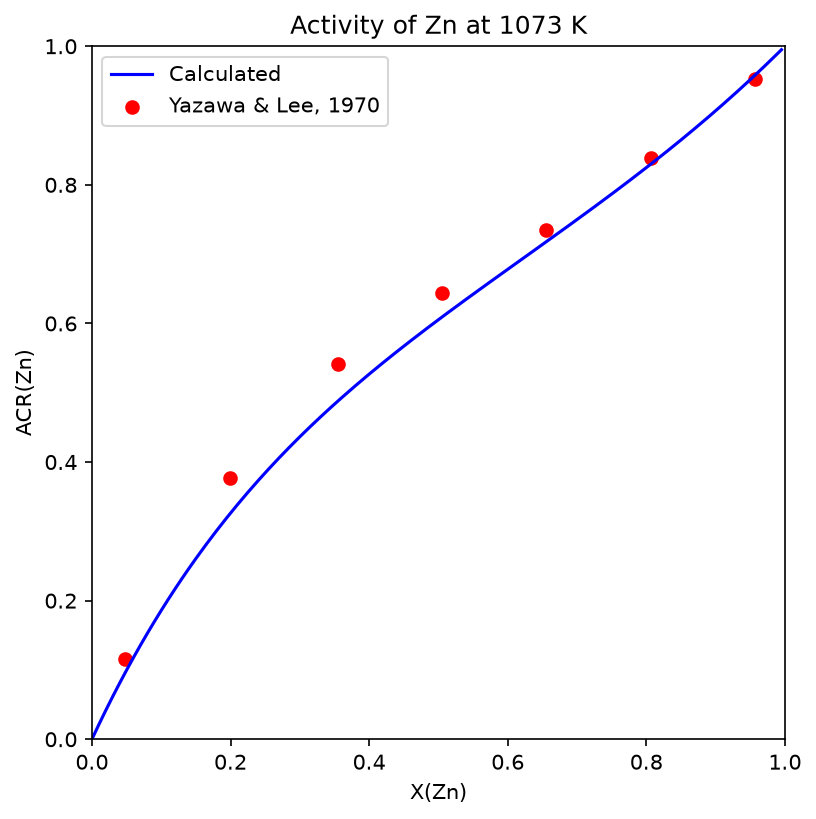

In [6]:
import matplotlib.pyplot as plt

plt.plot(eq.X.sel(component='ZN', vertex=0).squeeze(), acr_zn, label='Calculated', color='blue')

# add experimental data
plt.scatter(exp_x_zn, exp_acr_zn, label='Yazawa & Lee, 1970', color='red')

plt.xlim((0, 1))
plt.ylim((0, 1))
plt.gca().set_aspect(1)
plt.gcf().set_size_inches(9, 6)
plt.gcf().set_dpi(150)
plt.xlabel('X(Zn)')
plt.ylabel('ACR(Zn)')
plt.title(f'Activity of Zn at {temperature} K')
_ = plt.legend(loc=0)